# Adaptive Filtering — worked examples

The companion notebook to the [Adaptive Filtering
manual](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/adaptive-filtering.md). Same three examples,
same demo file, same numbers — computed here in a few lines of
`spwb.processing` instead of clicked in the application.

The manual carries the explanations and the history; this notebook is where
you change a parameter and watch what happens. Nothing here imports Qt, so
it runs anywhere `pip install spwb[io]` runs.

### Three ways to use this, needing progressively more

1. **Read it.** GitHub renders this file with every graph and number
   already in place. Nothing to install, nothing to run.
2. **Run it as a script** - no Jupyter involved at all:
   `python examples/manuals/adaptive_filtering.py`
3. **Run it cell by cell** in VS Code or Jupyter: change the taps, the
   step, the filter class, and watch the cancellation succeed or fail.

For (3), VS Code will ask which kernel to use. **Choose the Python
interpreter you installed SPWB into** - the same one `pip install -e .`
was run with. There is no separate "spwb" environment unless you created
one yourself. If it is not offered, run `pip install ipykernel` into it
and reopen the notebook.

| Section | Shows |
|---|---|
| 1 | A tone 4x below the noise, recovered to within 1 % |
| 2 | Filter length: the cliff at the length of the real path |
| 3 | Step size, and why "converged" does not mean "worked" |

Every section ends with an `assert` on the numbers the manual quotes.

## Setup

The demo datasets are generated rather than committed - they are 21 MB, and
`spwb.demo` reproduces them exactly from a fixed seed. The cell below
creates them if they are missing, so there is nothing to download. The
application offers the same thing under **File > Create Demo Data ...**.

In [1]:
from pathlib import Path

import numpy as np

try:                                    # notebook: draw figures inline
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:                       # plain script: draw to a buffer
    import warnings

    import matplotlib
    matplotlib.use("Agg")
    # plt.show() is a no-op under Agg and says so once per figure; the
    # figures are still built, and the notebook build uses the inline
    # backend where they are captured.
    warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
import matplotlib.pyplot as plt


def demo_folder() -> Path:
    """Where the demonstration datasets live.

    A git checkout keeps them in its own untracked ``.data/``. Anyone who
    installed the wheel has no checkout and gets them beside wherever they
    are working instead. Either way ``spwb.demo`` writes them on demand.
    """
    here = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
    for folder in (here, *here.parents):
        if (folder / "pyproject.toml").is_file() and (folder / "src").is_dir():
            return folder / ".data"
    return Path.cwd() / "spwb-demo-data"


DATA = demo_folder()

if not any(DATA.glob("[0-9][0-9]_*.h5")):
    from spwb.demo import write_demo_data

    print(f"creating the demonstration datasets in {DATA} ...")
    write_demo_data(DATA)

print(f"datasets : {len(list(DATA.glob('*.h5')))} files in {DATA}")

datasets : 14 files in <your pySPWB checkout>\.data


In [2]:
from spwb.processing.dsp import auto_power_spectrums, format_spectrum, signal_statistics
from spwb.processing.dsp.adaptive import LMS_FILTER_CLASSES, lms_filter
from spwb.processing.io import read_hdf5

signals = {s.name: s for s in read_hdf5(DATA / "14_LMS_Noise_cancellation.h5")}
NOISY = "Noisy (tone buried in noise)"
REFERENCE = "Reference (the noise source)"
TRUTH = "Wanted signal (ground truth)"

#: the hidden tone, and where the record has finished adapting
TONE_HZ, TONE_PEAK = 120.0, 0.5
SETTLED = signals[NOISY].n_samples // 2


def tone_amplitude(signal, f0=TONE_HZ):
    """Peak amplitude at the tone, read the way the FFT window would."""
    raw = auto_power_spectrums(signal, freq_resolution=1.0, window="flat_top")
    amp = format_spectrum(raw, function_type="Auto Spectrum - (EU Peak)")
    return float(amp.y[round(f0 / amp.dt)])


def residual(filtered):
    """RMS error against the ground truth, over the settled half."""
    error = np.asarray(filtered.y) - np.asarray(signals[TRUTH].y)
    return float(np.sqrt(np.mean(error[SETTLED:] ** 2)))


def run(*, taps=64, step=0.1, filter_class="Normalized LMS",
        reference=REFERENCE, noisy=NOISY):
    """One adaptive run, with the panel's defaults."""
    return lms_filter(signals[reference], signals[noisy],
                      filter_length=taps, step_size=step,
                      filter_class=filter_class)


print("ready")

ready


## 1. Rescuing a buried tone

**File:** `14_LMS_Noise_cancellation.h5` - a 120 Hz tone at 0.5 Pa peak
buried under noise that reached the microphone through a 31-tap filter.
The reference is the noise *before* that path; the clean tone is included
as ground truth so the answer can be checked.

Manual: [Worked example
1](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/adaptive-filtering.md#worked-example-1--rescuing-a-buried-tone).

In [3]:
print(f"  {'signal':34} {'rms':>9} {'120 Hz peak':>12}")
for name in (NOISY, REFERENCE, TRUTH):
    st = signal_statistics(signals[name])
    peak = tone_amplitude(signals[name]) if name != REFERENCE else float("nan")
    shown = f"{peak:12.5f}" if np.isfinite(peak) else f"{'-':>12}"
    print(f"  {name:34} {st.rms:9.5f} {shown}")

buried = (signal_statistics(signals[NOISY]).rms
          / signal_statistics(signals[TRUTH]).rms)
print(f"\n  the noisy recording is {buried:.2f}x the level of the tone "
      "hidden inside it")

  signal                                   rms  120 Hz peak
  Noisy (tone buried in noise)         1.47398      0.55189
  Reference (the noise source)         1.00135            -
  Wanted signal (ground truth)         0.35355      0.50000

  the noisy recording is 4.17x the level of the tone hidden inside it


In [4]:
result = run()

print(f"  level change  : {result.noise_reduction_db:+.2f} dB")
print(f"  convergence   : {result.convergence[-1]:.4f} "
      f"(chance level {result.noise_floor:.4f}) -> "
      f"{'converged' if result.converged else 'still adapting'}")
print(f"  filtered rms  : {signal_statistics(result.filtered).rms:.5f} Pa "
      f"(ground truth {signal_statistics(signals[TRUTH]).rms:.5f})")
print(f"  120 Hz peak   : {tone_amplitude(result.filtered):.5f} "
      f"(ground truth {TONE_PEAK:.5f})")
print(f"  residual      : {residual(result.filtered):.5f} Pa rms over the "
      "settled half")
print(f"\n  outputs: {result.filtered.name!r}")
print(f"           {result.removed.name!r}")

  level change  : +12.02 dB
  convergence   : 0.0331 (chance level 0.0793) -> converged
  filtered rms  : 0.36957 Pa (ground truth 0.35355)
  120 Hz peak   : 0.50591 (ground truth 0.50000)
  residual      : 0.07927 Pa rms over the settled half

  outputs: 'Noisy (tone buried in noise) (LMS)'
           'Noisy (tone buried in noise) (removed)'


**The filter did not just cancel the noise - it reconstructed the path.**
The demo's leak path is a 31-tap FIR scaled by 3.

In [5]:
from scipy import signal as ss

true_path = ss.firwin(31, 0.25) * 3.0
learned = result.coefficients

print(f"  true path : peak {true_path.max():.5f} at tap "
      f"{int(np.argmax(true_path))}")
print(f"  learned   : peak {np.abs(learned).max():.5f} at tap "
      f"{int(np.argmax(np.abs(learned)))}   ({len(learned)} taps)")
print(f"  agreement on the peak coefficient: "
      f"{100 * np.abs(learned).max() / true_path.max() - 100:+.1f} %")

  true path : peak 0.75216 at tap 15
  learned   : peak 0.76671 at tap 15   (64 taps)
  agreement on the peak coefficient: +1.9 %


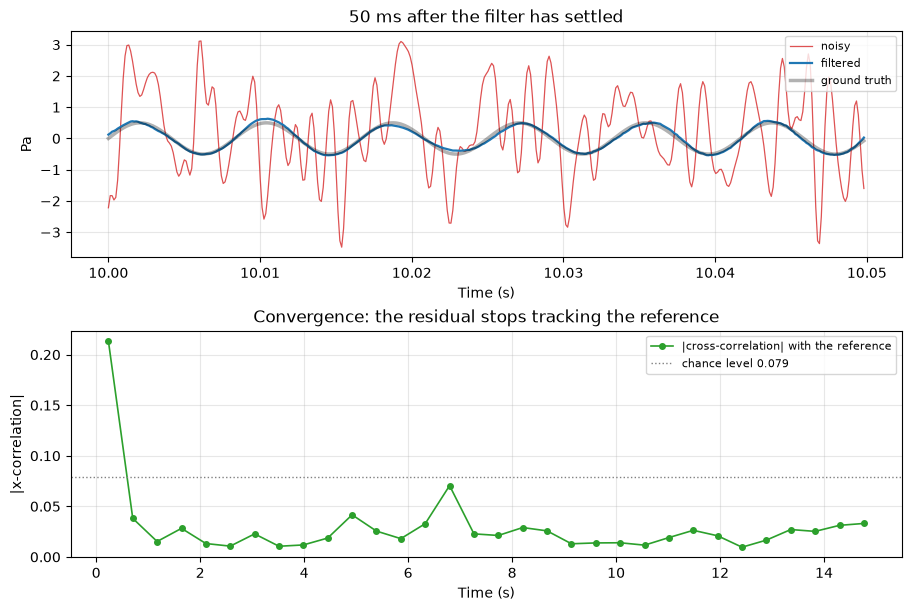

In [6]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(9, 6), constrained_layout=True)
window = slice(int(10.0 * signals[NOISY].fs), int(10.05 * signals[NOISY].fs))
top.plot(signals[NOISY].t[window], signals[NOISY].y[window], lw=0.9,
         color="tab:red", alpha=0.8, label="noisy")
top.plot(result.filtered.t[window], result.filtered.y[window], lw=1.6,
         color="tab:blue", label="filtered")
top.plot(signals[TRUTH].t[window], signals[TRUTH].y[window], lw=2.5,
         color="k", alpha=0.3, label="ground truth")
top.set(xlabel="Time (s)", ylabel="Pa",
        title="50 ms after the filter has settled")
top.legend(fontsize=8, loc="upper right")

bottom.plot(result.block_times, result.convergence, marker="o", ms=4, lw=1.2,
            color="tab:green", label="|cross-correlation| with the reference")
bottom.axhline(result.noise_floor, color="grey", ls=":", lw=1,
               label=f"chance level {result.noise_floor:.3f}")
bottom.set(xlabel="Time (s)", ylabel="|x-correlation|",
           title="Convergence: the residual stops tracking the reference")
bottom.legend(fontsize=8)
for ax in (top, bottom):
    ax.grid(True, alpha=0.3)
plt.show()

In [7]:
assert result.converged
assert result.noise_reduction_db > 11.0, result.noise_reduction_db
assert abs(tone_amplitude(result.filtered) - TONE_PEAK) < 0.02
assert residual(result.filtered) < 0.1
assert abs(np.abs(learned).max() - true_path.max()) < 0.05
print(f"section 1 OK - {result.noise_reduction_db:+.2f} dB, tone recovered at "
      f"{tone_amplitude(result.filtered):.4f} against a true 0.5")

section 1 OK - +12.02 dB, tone recovered at 0.5059 against a true 0.5


## 2. Filter length, the control that decides everything

The interference arrives through a 31-tap filter. A filter with fewer taps
than that **cannot represent the path**, however long it adapts.

Manual: [Worked example
2](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/adaptive-filtering.md#worked-example-2--filter-length-the-control-that-decides-everything).

In [8]:
print(f"  {'taps':>6} {'dB':>8} {'converged':>10} {'residual':>10}")
lengths = {}
for taps in (2, 4, 8, 16, 32, 64, 128, 256):
    r = run(taps=taps)
    lengths[taps] = (r.noise_reduction_db, r.converged, residual(r.filtered))
    print(f"  {taps:6d} {r.noise_reduction_db:8.2f} {r.converged!s:>10} "
          f"{residual(r.filtered):10.4f}")

print("\n  the cliff is between 16 and 32 taps - exactly where the filter "
      "becomes\n  long enough to hold the 31-tap impulse response. Below it "
      "the result is\n  worthless; above it, more taps buy almost nothing.")

    taps       dB  converged   residual
       2    -2.24       True     1.9788
       4    -0.43       True     1.5008
       8    -0.29       True     1.4753
      16     3.77      False     0.8836
      32    12.07       True     0.0818
      64    12.02       True     0.0793
     128    11.92       True     0.0758
     256    11.76       True     0.0728

  the cliff is between 16 and 32 taps - exactly where the filter becomes
  long enough to hold the 31-tap impulse response. Below it the result is
  worthless; above it, more taps buy almost nothing.


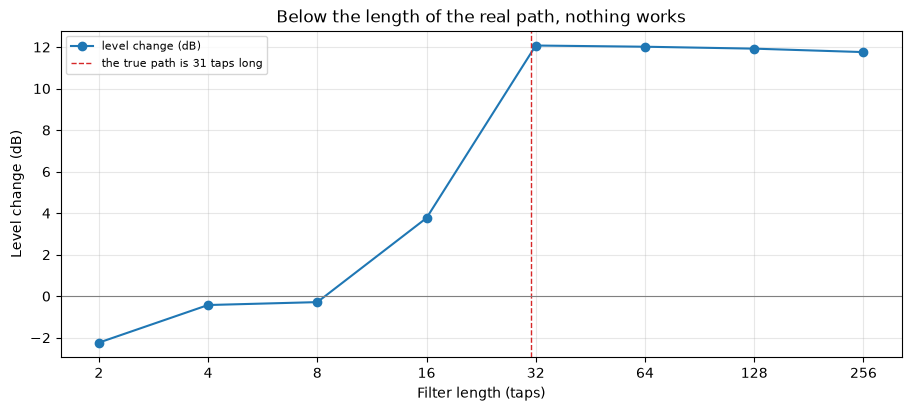

In [9]:
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
taps = sorted(lengths)
ax.semilogx(taps, [lengths[t][0] for t in taps], marker="o", lw=1.5,
            base=2, label="level change (dB)")
ax.axvline(31, color="tab:red", ls="--", lw=1,
           label="the true path is 31 taps long")
ax.axhline(0, color="grey", lw=0.8)
ax.set(xlabel="Filter length (taps)", ylabel="Level change (dB)",
       title="Below the length of the real path, nothing works")
ax.set_xticks(taps)
ax.set_xticklabels([str(t) for t in taps])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()

In [10]:
assert lengths[8][0] < 1.0, "a filter far too short cannot help"
assert lengths[32][0] > 11.0, "32 taps must clear the 31-tap path"
assert lengths[16][0] < lengths[32][0] - 5, "there must be a cliff"
assert lengths[256][2] < lengths[32][2] * 1.2, "more taps must not hurt much"
print(f"section 2 OK - {lengths[16][0]:.2f} dB at 16 taps against "
      f"{lengths[32][0]:.2f} dB at 32")

section 2 OK - 3.77 dB at 16 taps against 12.07 dB at 32


## 3. Step size, and what convergence does not tell you

Manual: [Worked example
3](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/adaptive-filtering.md#worked-example-3--step-size-and-what-convergence-does-not-tell-you).

In [11]:
print(f"  {'step':>7} {'dB':>8} {'residual':>10}   (accuracy once settled)")
steps = {}
for mu in (0.01, 0.05, 0.1, 0.5, 1.0, 1.5, 1.9):
    r = run(step=mu)
    steps[mu] = (r.noise_reduction_db, residual(r.filtered))
    print(f"  {mu:7g} {r.noise_reduction_db:8.2f} {residual(r.filtered):10.4f}")

print(f"\n  the two columns disagree and both are right: dB peaks at 0.1, but "
      f"the\n  accuracy is {steps[0.1][1] / steps[0.01][1]:.1f}x better at "
      "0.01. A small step converges slowly, so\n  more of the record is spent "
      "adapting and the total level drop is smaller -\n  but once settled it "
      "tracks far more precisely.")

     step       dB   residual   (accuracy once settled)
     0.01    10.82     0.0204
     0.05    11.96     0.0536
      0.1    12.02     0.0793
      0.5    11.08     0.2047
        1     9.24     0.3567
      1.5     6.13     0.6265
      1.9    -0.88     1.5775

  the two columns disagree and both are right: dB peaks at 0.1, but the
  accuracy is 3.9x better at 0.01. A small step converges slowly, so
  more of the record is spent adapting and the total level drop is smaller -
  but once settled it tracks far more precisely.


### "Converged" means the filter stopped learning, not that it worked

In [12]:
two_tap = run(taps=2)
print(f"  2 taps: convergence {two_tap.convergence[-1]:.4f} -> "
      f"{'converged' if two_tap.converged else 'still adapting'}, "
      f"level change {two_tap.noise_reduction_db:+.2f} dB")
print("  the filter made the recording WORSE and reported success.\n")
print("  The convergence trace answers one narrow question: does what is left")
print("  still correlate with the reference? With two taps the filter quickly")
print("  extracts everything two taps can explain, then stops improving - so")
print("  the metric is satisfied. It converged to a bad answer.\n")

swapped = run(reference=NOISY, noisy=REFERENCE)
print(f"  roles swapped: {swapped.noise_reduction_db:+.2f} dB  <- a negative "
      "number means\n  the reference does not carry the interference. Check "
      "which signal is which\n  before touching the step size.")

  2 taps: convergence 0.0469 -> converged, level change -2.24 dB
  the filter made the recording WORSE and reported success.

  The convergence trace answers one narrow question: does what is left
  still correlate with the reference? With two taps the filter quickly
  extracts everything two taps can explain, then stops improving - so
  the metric is satisfied. It converged to a bad answer.

  roles swapped: -2.86 dB  <- a negative number means
  the reference does not carry the interference. Check which signal is which
  before touching the step size.


### Filter classes, and the step size that is not the same number

In [13]:
print(f"  {'class':32} {'step':>6} {'dB':>8} {'residual':>10}")
for cls in LMS_FILTER_CLASSES:
    mu = 0.01 if cls == "LMS" else 0.1
    r = run(step=mu, filter_class=cls)
    print(f"  {cls:32} {mu:6g} {r.noise_reduction_db:8.2f} "
          f"{residual(r.filtered):10.4f}")
print("\n  the three normalised entries are the same algorithm - the Noise")
print("  Cancelling names are presets for which signal is wired where.\n")

try:
    run(step=1.0, filter_class="LMS")
except ValueError as exc:
    print("  plain LMS at the normalised default diverges, and says so with "
          "the\n  actual limit for THIS data rather than returning "
          "infinities:\n")
    print(f"    {exc}")

  class                              step       dB   residual
  LMS                                0.01    10.62     0.2421
  Normalized LMS                      0.1    12.02     0.0793
  Noise Cancelling (BGN Ref)          0.1    12.02     0.0793
  Noise Cancelling (Speech Ref)       0.1    12.02     0.0793

  the three normalised entries are the same algorithm - the Noise
  Cancelling names are presets for which signal is wired where.

  plain LMS at the normalised default diverges, and says so with the
  actual limit for THIS data rather than returning infinities:

    the filter diverged with 'LMS' at step size 1. Plain LMS is stable only for a step below about 0.0312 with this reference (64 taps, mean square 1.003). Reduce the step size, or use 'Normalized LMS', which rescales by the reference power and takes the documented 0 to 2 range.


In [14]:
for bad in (0.0, 2.0, -0.1):
    try:
        run(step=bad)
        raise AssertionError(f"step {bad} should have been refused")
    except ValueError:
        pass
assert steps[0.01][1] < steps[0.1][1], "a small step must be more accurate"
assert steps[1.9][0] < 1.0, "a step near 2 must stop working"
assert two_tap.converged and two_tap.noise_reduction_db < 0
assert swapped.noise_reduction_db < 0
print("section 3 OK - small steps are more accurate, 2 taps 'converges' to "
      f"{two_tap.noise_reduction_db:+.2f} dB, swapped roles give "
      f"{swapped.noise_reduction_db:+.2f} dB")

section 3 OK - small steps are more accurate, 2 taps 'converges' to -2.24 dB, swapped roles give -2.86 dB


## Where to go next

* The [Adaptive Filtering manual](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/adaptive-filtering.md)
  - the same three examples driven through the application, plus the
  history from Widrow and Hoff's 1960 learning rule to the fetal
  heartbeat that made the method famous.
* The other four manuals and their notebooks:
  [`time_processing.py`](https://github.com/Charette-AI-Group/pySPWB/blob/main/examples/manuals/time_processing.py),
  [`fft_analysis.py`](https://github.com/Charette-AI-Group/pySPWB/blob/main/examples/manuals/fft_analysis.py),
  [`transfer_function.py`](https://github.com/Charette-AI-Group/pySPWB/blob/main/examples/manuals/transfer_function.py),
  [`time_frequency.py`](https://github.com/Charette-AI-Group/pySPWB/blob/main/examples/manuals/time_frequency.py).
* `python tools/verify_demo_data.py` - the assertions that keep the demo
  datasets honest.

To use your own data, replace `signals` with `read_tdms("run.tdms")` or
`read_hdf5("measurement.h5")` and pick the two roles. The one thing that
matters is the reference: correlated with the interference, uncorrelated
with what you want to keep.

---

## Support This Work

If anything here was useful to you, please consider contributing.
SPWB is free and open source, and always will be — donations are
what let Charette AI Group keep maintaining it and open-sourcing
its other tools.

<p align="center">
  <a href="https://www.paypal.com/donate/?hosted_button_id=FEM4WLD7LHY36">
      <img src="https://www.paypalobjects.com/en_US/i/btn/btn_donateCC_LG.gif" alt="Donate with PayPal">
  </a>
</p>